# Targets generation

In [1]:
from src.targets_generation import Gaussian_seq

In [2]:
N = 500 # number of neurons
T = 10.5 # sequence length (in seconds)
dt = 0.001 # integration step (in seconds)
sigma = 0.3 # width of the gaussian curve
epsilon = 0.05

Choice of sigma: must be bigger than dt and smaller than T. Furthermore, sigma/T ~= N_active/N, which is equal to 0.3 as per the authors.

In [3]:
gs = Gaussian_seq(
    T = T,
    dt = dt
)
targets = gs.target_functions(
    T = T,
    sigma = sigma,
    N = N,
    epsilon = epsilon
)

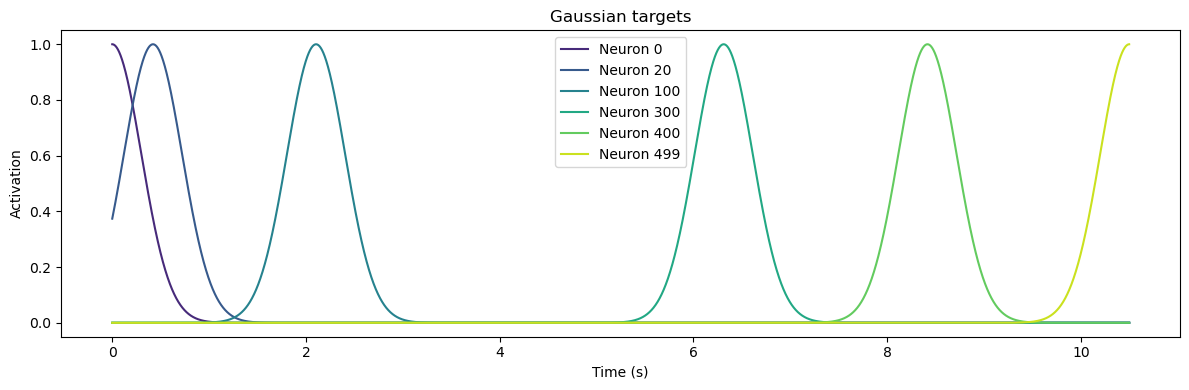

In [4]:
gs.gaussian_graph(
    T = 10.5,
    sigma = 0.3,
    N = 500, 
    neuron_list = [0, 20, 100, 300, 400, 499]
    )

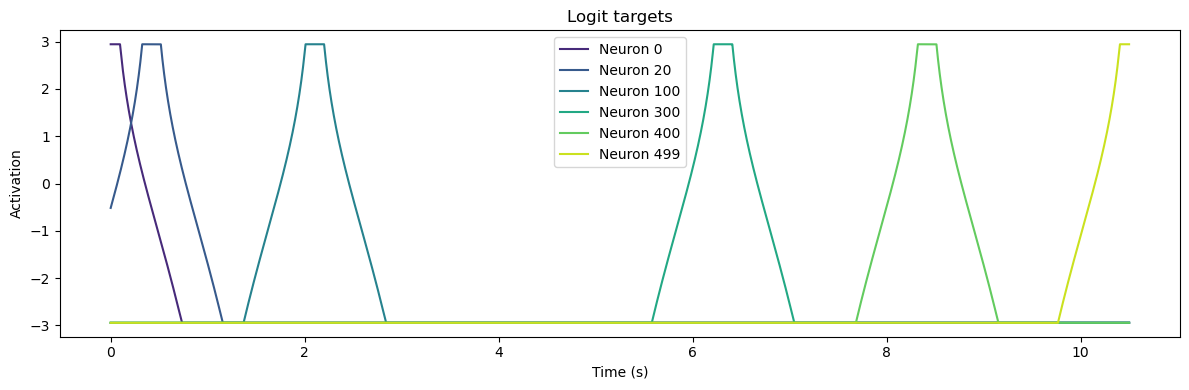

In [5]:
gs.target_graph(
    T = 10.5,
    sigma = 0.3,
    N = 500, 
    neuron_list = [0, 20, 100, 300, 400, 499],
    epsilon = epsilon
    )

# Inputs generation

In [6]:
from src.inputs_generation import Inputs

We define the external inputs of the network as filtered and spatially delocalized white noise, that is frozen, using this equation: \
$\tau_{WN} \displaystyle\frac{dh}{dt} = -h(t) + h_0 \eta (t)$,
for $\eta \sim \mathcal{N}(0, 1)$.

In [7]:
WN_tau = 1  # inputs' correlation time (in seconds)
h0 = 1 # inputs' scale

In [8]:
ipt = Inputs(T, dt)
inputs = ipt.inputs(N, WN_tau, h0)

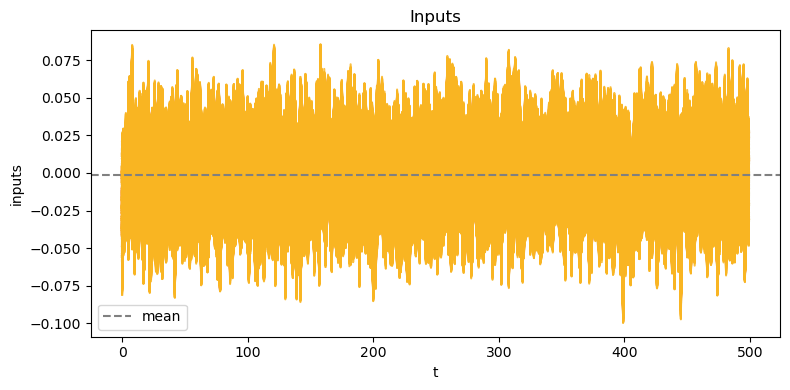

In [10]:
ipt.display_inputs(N, WN_tau, h0)

# Training

In [11]:
from src.training import RNN, PINning

Training parameters, fixed according to Rajan, Harvey & Tank (2016).

In [12]:
p = 0.08 # fraction of plastic synapses in the network
g = 1.5 # chaos parameter
tau = 0.01 # membrane time constant (in seconds)
theta = 0 # sigmoid threshold
p0 = 10 # initial P matrix scaling factor: amplitude of 1 to 10 times h0
n_runs = 500 # number of training steps to learn J
n_steps = 50 # number of additionnal steps where J is not modified
cv_threshold = 0.02 # error value at which we deem the model to converge

In [13]:
print(f"targets mean : {targets.mean():.4f}")  
print(f"targets std  : {targets.std():.4f}")   
print(f"targets max  : {targets.max():.4f}")   
print(f"targets min  : {targets.min():.4f}")  

targets mean : -2.5331
targets std  : 1.2397
targets max  : 2.9444
targets min  : -2.9444


Run 1 | run_error=0.186270 | e mean=0.4840 | e std=0.4546 | z mean=-2.2438 | target mean=-2.5331
Run 2 | run_error=0.366840 | e mean=0.4716 | e std=0.6897 | z mean=-2.2562 | target mean=-2.5331
Run 3 | run_error=0.430159 | e mean=0.0802 | e std=1.0666 | z mean=-2.6477 | target mean=-2.5331
Run 4 | run_error=0.409357 | e mean=0.4880 | e std=0.7756 | z mean=-2.2398 | target mean=-2.5331
Run 5 | run_error=0.301521 | e mean=0.4617 | e std=0.7103 | z mean=-2.2661 | target mean=-2.5331
Run 6 | run_error=0.557449 | e mean=0.4784 | e std=0.7465 | z mean=-2.2494 | target mean=-2.5331
Run 7 | run_error=1.251999 | e mean=0.4669 | e std=0.7555 | z mean=-2.2609 | target mean=-2.5331
Run 8 | run_error=0.448588 | e mean=-0.0558 | e std=1.2464 | z mean=-2.7836 | target mean=-2.5331
Run 9 | run_error=0.446540 | e mean=0.4610 | e std=0.7822 | z mean=-2.2669 | target mean=-2.5331
Run 10 | run_error=0.282007 | e mean=0.4465 | e std=0.7269 | z mean=-2.2813 | target mean=-2.5331
Run 11 | run_error=0.372966 

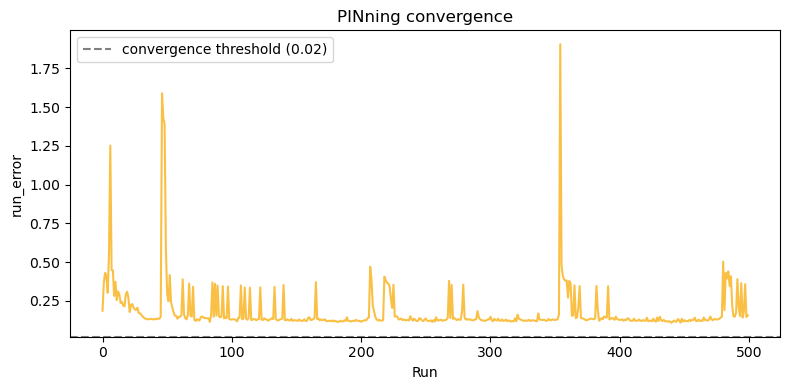

In [14]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors = PINned_model.train(inputs, n_runs, cv_threshold, DEBUG = True)
PINned_model.display_cv(errors)

In [15]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)

# Evaluation

In [16]:
threshold = 0.95

In [17]:
from src.evaluation import Metrics

In [18]:
Metrics.general_evaluation(rates = final_rates, targets = targets, t = gs.t, sigma = sigma, threshold = threshold)

,,bVar,pVar,Qeff
0,Model's metrics,-0.370782,-4.43929,14
1,Article's metrics,1,0.9,trueval


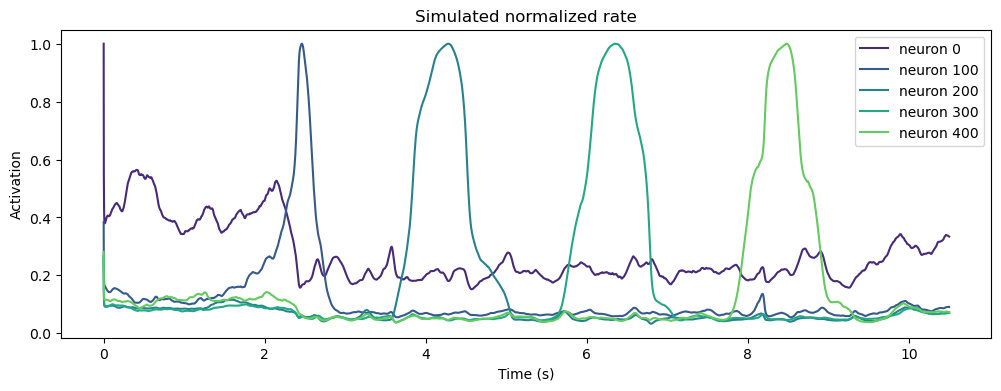

In [19]:
neuron_list = [0, 100, 200, 300, 400]
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

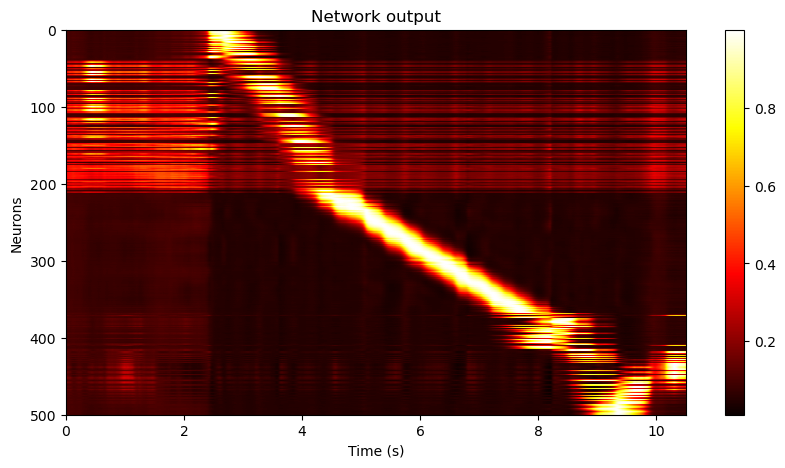

In [24]:
import numpy as np
import matplotlib.pyplot as plt

norm_rates = Metrics.normalize(final_rates)

tCOM = Metrics.compute_tCOM(norm_rates, gs.t)
sort_idx = np.argsort(tCOM)

plt.figure(figsize=(10,5))
plt.imshow(norm_rates[sort_idx], aspect='auto', extent=[0, T, N, 0], cmap='hot')
plt.colorbar()
plt.xlabel('Time (s)')
plt.ylabel('Neurons')
plt.title('Network output')
plt.show()

In [25]:
print(f"plastic_neurons : {sorted(PINned_model.plastic_neurons)[:10]} ... {sorted(PINned_model.plastic_neurons)[-10:]}")

plastic_neurons : [16, 45, 59, 64, 68, 75, 93, 103, 110, 118] ... [373, 379, 384, 390, 393, 427, 431, 433, 440, 442]
